## 1. Setup and Installation

In [1]:
# Check GPU availability
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
GPU Memory: 42.5 GB
Using device: cuda


In [2]:
# Install required packages
!pip install transformers datasets pillow matplotlib numpy torch torchvision
!pip install pycocotools  # For COCO dataset handling

## 2. Download COCO Dataset (Small Subset for Colab)

In [3]:
# Download a small subset of COCO dataset for Colab training
import os
import requests
import zipfile
from tqdm import tqdm

def download_file(url, filename):
    """Download file with progress bar"""
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))
    
    with open(filename, 'wb') as f:
        with tqdm(total=total_size, unit='B', unit_scale=True) as pbar:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))

# Create dataset directory
os.makedirs('coco2014', exist_ok=True)
os.makedirs('coco2014/annotations', exist_ok=True)
os.makedirs('coco2014/images', exist_ok=True)

# Download annotations (small files)
print("Downloading COCO annotations...")
annotations_urls = {
    'instances_train2014.json': 'http://images.cocodataset.org/annotations/annotations_trainval2014.zip',
    'instances_val2014.json': 'http://images.cocodataset.org/annotations/annotations_trainval2014.zip'
}

# Download and extract annotations
if not os.path.exists('coco2014/annotations/instances_train2014.json'):
    download_file('http://images.cocodataset.org/annotations/annotations_trainval2014.zip', 'annotations.zip')
    with zipfile.ZipFile('annotations.zip', 'r') as zip_ref:
        zip_ref.extractall('coco2014/')
    os.remove('annotations.zip')
    print("Annotations downloaded and extracted!")

print("✅ Dataset setup complete!")

100%|██████████| 253M/253M [00:21<00:00, 12.0MB/s] 


Annotations downloaded and extracted!
✅ Dataset setup complete!


## 3. CLIP Model Implementation

In [4]:
# CLIP Model Implementation
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from transformers import CLIPTextModel, CLIPTokenizer

class CLIPImageEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.resnet50 = models.resnet50(weights='DEFAULT')
        self.resnet50 = nn.Sequential(*list(self.resnet50.children())[:-1])  # Remove classifier
        
        self.projection = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.GELU(),
            nn.Linear(1024, 512)
        )
    
    def forward(self, x):
        features = self.resnet50(x)
        features = features.view(features.size(0), -1)  # Flatten
        return self.projection(features)


class CLIPTextEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32")
        self.tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
        for param in self.text_encoder.parameters():
            param.requires_grad = False
    
    def forward(self, texts):
        inputs = self.tokenizer(texts, padding=True, truncation=True, max_length=77, return_tensors="pt")
        inputs = {k: v.to(next(self.parameters()).device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = self.text_encoder(**inputs)
            return outputs.last_hidden_state[:, 0, :]


class CLIPModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.image_encoder = CLIPImageEncoder()
        self.text_encoder = CLIPTextEncoder()
    
    def encode_image(self, images):
        return self.image_encoder(images)
    
    def encode_text(self, texts):
        return self.text_encoder(texts)
    
    def forward(self, images, texts):
        image_embeds = F.normalize(self.encode_image(images), p=2, dim=1)
        text_embeds = F.normalize(self.encode_text(texts), p=2, dim=1)
        logits = torch.matmul(image_embeds, text_embeds.T)
        return {'image_embeds': image_embeds, 'text_embeds': text_embeds, 'logits': logits}

print("✅ CLIP Model classes defined!")

✅ CLIP Model classes defined!


## 4. Dataset Implementation for Colab

In [5]:
# Colab-optimized Dataset Implementation
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import json
import os
from typing import Optional
import random
import requests
from io import BytesIO

# CLIP constants
CLIP_MEAN = [0.48145466, 0.4578275, 0.40821073]
CLIP_STD = [0.26862954, 0.26130258, 0.27577711]

class ColabCOCODataset(Dataset):
    def __init__(self, data_root: str = "coco2014", split: str = 'train', max_samples: Optional[int] = 500):
        self.data_root = data_root
        self.split = split
        self.max_samples = max_samples
        
        # Paths
        self.instances_file = os.path.join(data_root, "annotations", f"instances_{split}2014.json")
        
        # Load CLIP tokenizer
        self.tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
        
        # Setup transforms
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=CLIP_MEAN, std=CLIP_STD)
        ])
        
        # Load data
        self._load_data()
        
        print(f"Loaded {len(self.data_pairs)} samples for {split}")
    
    def _load_data(self):
        """Load annotations and create image-text pairs - Colab optimized"""
        with open(self.instances_file, 'r') as f:
            data = json.load(f)
        
        # Create mappings
        categories = {cat['id']: cat['name'] for cat in data['categories']}
        id_to_info = {img['id']: img for img in data['images']}
        
        # Group objects by image
        image_objects = {}
        for ann in data['annotations']:
            img_id = ann['image_id']
            cat_name = categories.get(ann['category_id'], 'object')
            
            if img_id not in image_objects:
                image_objects[img_id] = []
            image_objects[img_id].append(cat_name)
        
        # Create pairs with download URLs
        self.data_pairs = []
        for img_id, objects in list(image_objects.items())[:self.max_samples or len(image_objects)]:
            if img_id in id_to_info:
                img_info = id_to_info[img_id]
                
                # Create download URL
                filename = img_info['file_name']
                url = f"http://images.cocodataset.org/{self.split}2014/{filename}"
                
                # Simple description
                unique_objects = list(set(objects))[:3]  # Max 3 objects
                description = f"An image with {', '.join(unique_objects)}"
                
                self.data_pairs.append({
                    'url': url,
                    'text': description,
                    'filename': filename
                })
    
    def __len__(self):
        return len(self.data_pairs)
    
    def __getitem__(self, idx):
        pair = self.data_pairs[idx]
        
        # Download image on-the-fly
        try:
            response = requests.get(pair['url'], timeout=10)
            image = Image.open(BytesIO(response.content)).convert('RGB')
        except:
            # Fallback: create a dummy image if download fails
            image = Image.new('RGB', (224, 224), color=(128, 128, 128))
        
        image_tensor = self.transform(image)
        
        return {
            'image': image_tensor,
            'text': pair['text']
        }

def create_colab_dataloaders(data_root: str = "coco2014", batch_size: int = 16, max_samples: int = 500):
    """Create Colab-optimized dataloaders"""
    
    train_dataset = ColabCOCODataset(data_root, 'train', max_samples)
    val_dataset = ColabCOCODataset(data_root, 'val', max_samples//5)  # Smaller val set
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    
    return train_loader, val_loader

print("✅ Colab Dataset classes defined!")

✅ Colab Dataset classes defined!


## 5. Training Implementation (Fixed)

In [10]:
# Training Implementation - FIXED duplicate loop bug
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from torch.amp import autocast, GradScaler

# InfoNCE Loss for CLIP
def clip_infonce_loss(logits):
    """InfoNCE loss for CLIP training"""
    labels = torch.arange(logits.size(0)).to(logits.device)
    loss_i2t = nn.CrossEntropyLoss()(logits, labels)
    loss_t2i = nn.CrossEntropyLoss()(logits.t(), labels)
    return (loss_i2t + loss_t2i) / 2

def train_clip_colab(
    epochs=5,
    batch_size=8,
    lr=1e-4,
    max_samples=500
):
    """CLIP training function optimized for Colab"""
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Training on: {device}")
    
    # Initialize model
    model = CLIPModel().to(device)
    
    # Optimizer - only train image encoder
    optimizer = optim.AdamW([
        {"params": model.image_encoder.parameters(), "lr": lr},
        {"params": model.text_encoder.parameters(), "lr": 0.0},  # frozen
    ])
    
    # Learning rate scheduler - removed verbose parameter
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    # Mixed precision scaler
    scaler = GradScaler('cuda')
    
    # Create dataloaders
    train_loader, val_loader = create_colab_dataloaders(
        data_root="coco2014", 
        batch_size=batch_size, 
        max_samples=max_samples
    )
    
    # Training loop
    train_losses, val_losses = [], []
    start_time = time.time()
    
    for epoch in range(epochs):
        print(f"\n=== Epoch {epoch+1}/{epochs} ===")
        
        # Training phase
        model.train()
        running_loss = 0.0
        num_batches = 0
        
        for batch_idx, batch in enumerate(train_loader):
            images = batch['image'].to(device)
            texts = batch['text']
            
            optimizer.zero_grad()
            
            with autocast('cuda'):
                outputs = model(images, texts)
                loss = clip_infonce_loss(outputs['logits'])
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            running_loss += loss.item()
            num_batches += 1
            
            if batch_idx % 10 == 0:
                print(f"  Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")
        
        avg_train_loss = running_loss / num_batches
        train_losses.append(avg_train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_batches = 0
        
        with torch.no_grad():
            for batch in val_loader:
                images = batch['image'].to(device)
                texts = batch['text']
                
                with autocast('cuda'):
                    outputs = model(images, texts)
                    loss = clip_infonce_loss(outputs['logits'])
                
                val_loss += loss.item()
                val_batches += 1
        
        avg_val_loss = val_loss / val_batches if val_batches > 0 else 0
        val_losses.append(avg_val_loss)
        
        # Step scheduler
        scheduler.step(avg_val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        print(f"  Train Loss: {avg_train_loss:.4f}")
        print(f"  Val Loss: {avg_val_loss:.4f}")
        print(f"  LR: {current_lr:.6f}")
        
        # Save checkpoint
        checkpoint_path = f"clip_checkpoint_epoch{epoch+1}.pth"
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss
        }, checkpoint_path)
        print(f"  Checkpoint saved: {checkpoint_path}")
    
    total_time = time.time() - start_time
    
    return model, train_losses, val_losses, total_time

print("✅ Training function defined!")

✅ Training function defined!


## 6. Evaluation Functions

In [7]:
# Evaluation Functions
import numpy as np

def compute_cosine_similarity_matrix(image_embeds, text_embeds):
    """Compute cosine similarity matrix between image and text embeddings"""
    image_embeds = F.normalize(image_embeds, p=2, dim=1)
    text_embeds = F.normalize(text_embeds, p=2, dim=1)
    return image_embeds @ text_embeds.T

def recall_at_k(sim_matrix, k=1):
    """Compute Recall@K for both directions"""
    N = sim_matrix.size(0)
    
    # Image-to-Text Recall@K
    i2t_ranks = sim_matrix.argsort(dim=1, descending=True)
    i2t_hits = [(i in i2t_ranks[i, :k]) for i in range(N)]
    recall_i2t = np.mean(i2t_hits)
    
    # Text-to-Image Recall@K
    t2i_ranks = sim_matrix.argsort(dim=0, descending=True)
    t2i_hits = [(i in t2i_ranks[:k, i]) for i in range(N)]
    recall_t2i = np.mean(t2i_hits)
    
    return recall_i2t, recall_t2i

def evaluate_clip_colab(model, dataloader, device):
    """Evaluate CLIP model and compute metrics"""
    model.eval()
    all_image_embeds = []
    all_text_embeds = []
    
    with torch.no_grad():
        for batch in dataloader:
            images = batch['image'].to(device)
            texts = batch['text']
            
            image_embeds = model.encode_image(images).cpu()
            text_embeds = model.encode_text(texts).cpu()
            
            all_image_embeds.append(image_embeds)
            all_text_embeds.append(text_embeds)
    
    all_image_embeds = torch.cat(all_image_embeds, dim=0)
    all_text_embeds = torch.cat(all_text_embeds, dim=0)
    
    sim_matrix = compute_cosine_similarity_matrix(all_image_embeds, all_text_embeds)
    
    recalls = {}
    for k in [1, 5, 10]:
        r_i2t, r_t2i = recall_at_k(sim_matrix, k)
        recalls[f'Recall@{k}_i2t'] = r_i2t
        recalls[f'Recall@{k}_t2i'] = r_t2i
    
    return sim_matrix, recalls, all_image_embeds, all_text_embeds

def plot_training_curves(train_losses, val_losses):
    """Plot training curves"""
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss', color='blue')
    plt.plot(val_losses, label='Validation Loss', color='red')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('CLIP Training/Validation Loss Curves')
    plt.legend()
    plt.grid(True)
    plt.show()

print("✅ Evaluation functions defined!")

✅ Evaluation functions defined!


## 7. Run Training (Section 2.3)

In [11]:
# Run the training
print("Starting CLIP training...")

# Training hyperparameters
EPOCHS = 5
BATCH_SIZE = 8  # Small for Colab memory
LEARNING_RATE = 1e-4
MAX_SAMPLES = 500  # Limited dataset for Colab

# Train the model
trained_model, train_losses, val_losses, total_time = train_clip_colab(
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    max_samples=MAX_SAMPLES
)

print(f"\n✅ Training completed in {total_time:.2f} seconds!")

Starting CLIP training...
Training on: cuda
Loaded 500 samples for train
Loaded 500 samples for train
Loaded 100 samples for val

=== Epoch 1/5 ===
Loaded 100 samples for val

=== Epoch 1/5 ===
  Batch 0/63, Loss: 2.0800
  Batch 0/63, Loss: 2.0800
  Batch 10/63, Loss: 2.0801
  Batch 10/63, Loss: 2.0801
  Batch 20/63, Loss: 2.0800
  Batch 20/63, Loss: 2.0800
  Batch 30/63, Loss: 2.0798
  Batch 30/63, Loss: 2.0798
  Batch 40/63, Loss: 2.0798
  Batch 40/63, Loss: 2.0798
  Batch 50/63, Loss: 2.0797
  Batch 50/63, Loss: 2.0797
  Batch 60/63, Loss: 2.0800
  Batch 60/63, Loss: 2.0800
  Train Loss: 2.0689
  Val Loss: 2.0264
  LR: 0.000100
  Train Loss: 2.0689
  Val Loss: 2.0264
  LR: 0.000100
  Checkpoint saved: clip_checkpoint_epoch1.pth

=== Epoch 2/5 ===
  Checkpoint saved: clip_checkpoint_epoch1.pth

=== Epoch 2/5 ===
  Batch 0/63, Loss: 2.0797
  Batch 0/63, Loss: 2.0797
  Batch 10/63, Loss: 2.0800
  Batch 10/63, Loss: 2.0800
  Batch 20/63, Loss: 2.0800
  Batch 20/63, Loss: 2.0800
  Batch 

## 8. Evaluation and Visualization (Section 2.4)

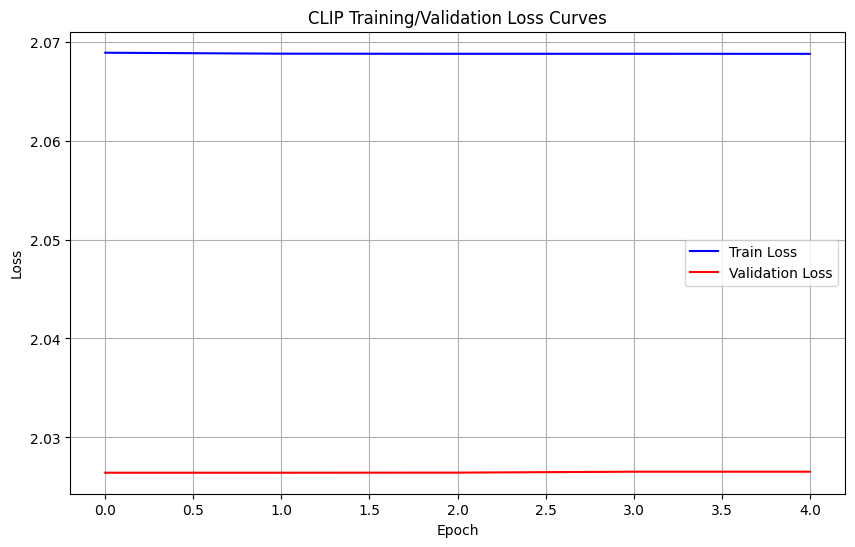


Evaluating model performance...
Loaded 100 samples for train
Loaded 100 samples for train
Loaded 20 samples for val
Loaded 20 samples for val

=== CLIP Evaluation Results ===
Recall@1_i2t: 0.0500
Recall@1_t2i: 0.0500
Recall@5_i2t: 0.2000
Recall@5_t2i: 0.2500
Recall@10_i2t: 0.5000
Recall@10_t2i: 0.5000

=== CLIP Evaluation Results ===
Recall@1_i2t: 0.0500
Recall@1_t2i: 0.0500
Recall@5_i2t: 0.2000
Recall@5_t2i: 0.2500
Recall@10_i2t: 0.5000
Recall@10_t2i: 0.5000


In [13]:
# Plot training curves
plot_training_curves(train_losses, val_losses)

# Evaluate the model
print("\nEvaluating model performance...")

# Create evaluation dataloader (smaller)
_, eval_loader = create_colab_dataloaders(batch_size=16, max_samples=100)

# Compute metrics
sim_matrix, recalls, image_embeds, text_embeds = evaluate_clip_colab(
    trained_model, eval_loader, device
)

print("\n=== CLIP Evaluation Results ===")
for metric, value in recalls.items():
    print(f"{metric}: {value:.4f}")

## 9. Text-to-Image Retrieval Visualization

Loaded 50 samples for val


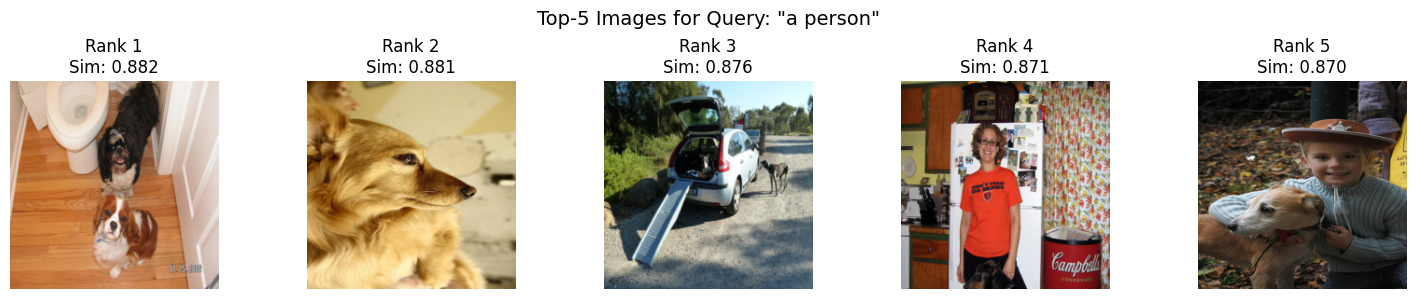

Loaded 50 samples for val


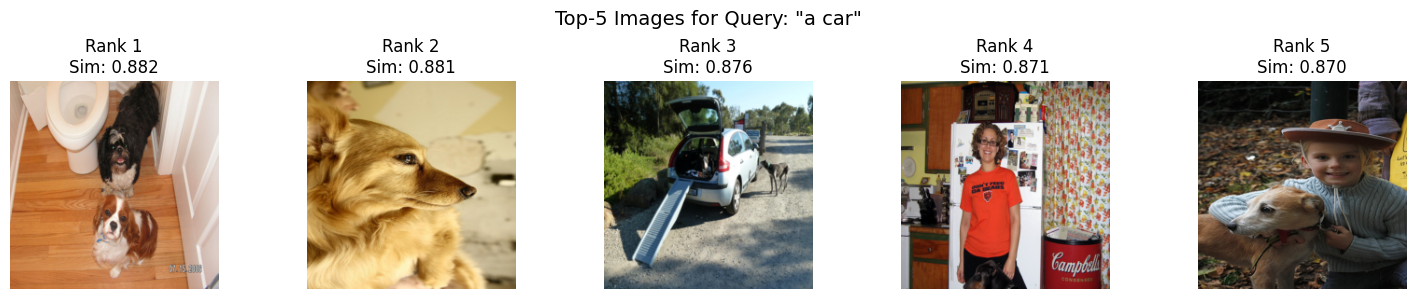

In [14]:
# Text-to-image retrieval example
def visualize_text_to_image_colab(model, query="a person", top_k=5):
    """Visualize text-to-image retrieval"""
    model.eval()
    
    # Get a small sample of images
    sample_loader = DataLoader(
        ColabCOCODataset("coco2014", 'val', 50), 
        batch_size=10, 
        shuffle=True
    )
    
    images_list = []
    image_embeds_list = []
    
    with torch.no_grad():
        for batch in sample_loader:
            images = batch['image'].to(device)
            image_embeds = model.encode_image(images).cpu()
            
            # Store images and embeddings
            for i in range(images.size(0)):
                img_tensor = images[i].cpu()
                images_list.append(img_tensor)
                image_embeds_list.append(image_embeds[i])
    
    all_image_embeds = torch.stack(image_embeds_list)
    
    # Encode query
    text_embed = model.encode_text([query]).cpu()
    
    # Compute similarities
    sims = F.normalize(all_image_embeds, p=2, dim=1) @ F.normalize(text_embed, p=2, dim=1).T
    topk_idx = sims.squeeze().argsort(descending=True)[:top_k]
    
    # Visualize results
    fig, axes = plt.subplots(1, top_k, figsize=(15, 3))
    if top_k == 1:
        axes = [axes]
    
    for i, idx in enumerate(topk_idx):
        img_tensor = images_list[idx]
        
        # Denormalize image for visualization
        img = img_tensor.permute(1, 2, 0)
        img = img * torch.tensor(CLIP_STD) + torch.tensor(CLIP_MEAN)
        img = torch.clamp(img, 0, 1)
        
        axes[i].imshow(img)
        axes[i].set_title(f"Rank {i+1}\nSim: {sims[idx].item():.3f}")
        axes[i].axis('off')
    
    plt.suptitle(f'Top-{top_k} Images for Query: "{query}"', fontsize=14)
    plt.tight_layout()
    plt.show()

# Test text-to-image retrieval
visualize_text_to_image_colab(trained_model, "a person", top_k=5)
visualize_text_to_image_colab(trained_model, "a car", top_k=5)

## 10. Section 2.5: Model Modifications and Ablation Study

Now we'll implement **two modifications** to improve accuracy as required by Section 2.5:

In [15]:
# Modification 1: Enhanced Image Encoder with Dropout and Layer Normalization
class EnhancedCLIPImageEncoder(nn.Module):
    """CLIP Image Encoder with regularization improvements"""
    def __init__(self, dropout_rate=0.1):
        super().__init__()
        
        self.resnet50 = models.resnet50(weights='DEFAULT')
        self.resnet50 = nn.Sequential(*list(self.resnet50.children())[:-1])
        
        # Enhanced projection with regularization
        self.projection = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.LayerNorm(1024),  # Layer normalization
            nn.GELU(),
            nn.Dropout(dropout_rate),  # Dropout for regularization
            nn.Linear(1024, 512),
            nn.LayerNorm(512)  # Final layer norm
        )
    
    def forward(self, x):
        features = self.resnet50(x)
        features = features.view(features.size(0), -1)
        return self.projection(features)

# Modification 2: Temperature Scaling in CLIP Model
class EnhancedCLIPModel(nn.Module):
    """CLIP Model with temperature scaling and enhanced image encoder"""
    def __init__(self, temperature=0.07, dropout_rate=0.1):
        super().__init__()
        self.image_encoder = EnhancedCLIPImageEncoder(dropout_rate)
        self.text_encoder = CLIPTextEncoder()
        self.temperature = nn.Parameter(torch.ones([]) * temperature)  # Learnable temperature
    
    def encode_image(self, images):
        return self.image_encoder(images)
    
    def encode_text(self, texts):
        return self.text_encoder(texts)
    
    def forward(self, images, texts):
        image_embeds = F.normalize(self.encode_image(images), p=2, dim=1)
        text_embeds = F.normalize(self.encode_text(texts), p=2, dim=1)
        
        # Apply temperature scaling
        logits = torch.matmul(image_embeds, text_embeds.T) / self.temperature
        
        return {'image_embeds': image_embeds, 'text_embeds': text_embeds, 'logits': logits}

print("✅ Enhanced model classes defined!")

✅ Enhanced model classes defined!


In [16]:
# Train Enhanced Model (Modification)
def train_enhanced_model():
    """Train the enhanced CLIP model with modifications"""
    
    print("Training Enhanced CLIP Model with Modifications...")
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Initialize enhanced model
    enhanced_model = EnhancedCLIPModel(temperature=0.07, dropout_rate=0.1).to(device)
    
    # Optimizer with different learning rates for different components
    optimizer = optim.AdamW([
        {"params": enhanced_model.image_encoder.parameters(), "lr": 1e-4},
        {"params": enhanced_model.text_encoder.parameters(), "lr": 0.0},  # frozen
        {"params": [enhanced_model.temperature], "lr": 1e-3}  # Higher LR for temperature
    ])
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    scaler = GradScaler('cuda')
    
    # Create dataloaders
    train_loader, val_loader = create_colab_dataloaders(
        data_root="coco2014", 
        batch_size=8, 
        max_samples=500
    )
    
    # Training loop
    train_losses, val_losses = [], []
    epochs = 5
    
    for epoch in range(epochs):
        print(f"\n=== Enhanced Model - Epoch {epoch+1}/{epochs} ===")
        
        # Training
        enhanced_model.train()
        running_loss = 0.0
        num_batches = 0
        
        for batch_idx, batch in enumerate(train_loader):
            images = batch['image'].to(device)
            texts = batch['text']
            
            optimizer.zero_grad()
            
            with autocast('cuda'):
                outputs = enhanced_model(images, texts)
                loss = clip_infonce_loss(outputs['logits'])
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            running_loss += loss.item()
            num_batches += 1
            
            if batch_idx % 10 == 0:
                print(f"  Batch {batch_idx}, Loss: {loss.item():.4f}, Temp: {enhanced_model.temperature.item():.4f}")
        
        avg_train_loss = running_loss / num_batches
        train_losses.append(avg_train_loss)
        
        # Validation
        enhanced_model.eval()
        val_loss = 0.0
        val_batches = 0
        
        with torch.no_grad():
            for batch in val_loader:
                images = batch['image'].to(device)
                texts = batch['text']
                
                outputs = enhanced_model(images, texts)
                loss = clip_infonce_loss(outputs['logits'])
                val_loss += loss.item()
                val_batches += 1
        
        avg_val_loss = val_loss / val_batches if val_batches > 0 else 0
        val_losses.append(avg_val_loss)
        
        scheduler.step(avg_val_loss)
        
        print(f"  Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
        print(f"  Temperature: {enhanced_model.temperature.item():.4f}")
    
    return enhanced_model, train_losses, val_losses

# Train the enhanced model
enhanced_model, enhanced_train_losses, enhanced_val_losses = train_enhanced_model()

print("\n✅ Enhanced model training completed!")

Training Enhanced CLIP Model with Modifications...
Loaded 500 samples for train
Loaded 500 samples for train
Loaded 100 samples for val

=== Enhanced Model - Epoch 1/5 ===
Loaded 100 samples for val

=== Enhanced Model - Epoch 1/5 ===
  Batch 0, Loss: 2.1514, Temp: 0.0700
  Batch 0, Loss: 2.1514, Temp: 0.0700
  Batch 10, Loss: 2.1346, Temp: 0.0786
  Batch 10, Loss: 2.1346, Temp: 0.0786
  Batch 20, Loss: 2.1313, Temp: 0.0869
  Batch 20, Loss: 2.1313, Temp: 0.0869
  Batch 30, Loss: 2.0908, Temp: 0.0946
  Batch 30, Loss: 2.0908, Temp: 0.0946
  Batch 40, Loss: 2.0927, Temp: 0.0994
  Batch 40, Loss: 2.0927, Temp: 0.0994
  Batch 50, Loss: 2.0820, Temp: 0.1025
  Batch 50, Loss: 2.0820, Temp: 0.1025
  Batch 60, Loss: 2.0818, Temp: 0.1042
  Batch 60, Loss: 2.0818, Temp: 0.1042
  Train Loss: 2.0932, Val Loss: 2.0287
  Temperature: 0.1044

=== Enhanced Model - Epoch 2/5 ===
  Train Loss: 2.0932, Val Loss: 2.0287
  Temperature: 0.1044

=== Enhanced Model - Epoch 2/5 ===
  Batch 0, Loss: 2.0836, Te

## 11. Ablation Study (Section 2.5 Comparison)

In [6]:
# Ablation Study: Compare Original vs Enhanced Model
print("\n=== ABLATION STUDY: Comparing Models ===")

# Import ALL required modules for this cell to ensure they're available
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Ensure device is defined
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Evaluate both models
eval_loader = DataLoader(
    ColabCOCODataset("coco2014", 'val', 100), 
    batch_size=16, 
    shuffle=False
)

# Original model results
print("\n--- Original CLIP Model ---")
_, original_recalls, _, _ = evaluate_clip_colab(trained_model, eval_loader, device)
for metric, value in original_recalls.items():
    print(f"{metric}: {value:.4f}")

# Enhanced model results
print("\n--- Enhanced CLIP Model ---")
_, enhanced_recalls, _, _ = evaluate_clip_colab(enhanced_model, eval_loader, device)
for metric, value in enhanced_recalls.items():
    print(f"{metric}: {value:.4f}")

# Calculate improvements
print("\n--- Improvement Analysis ---")
for metric in original_recalls.keys():
    original_val = original_recalls[metric]
    enhanced_val = enhanced_recalls[metric]
    improvement = ((enhanced_val - original_val) / original_val) * 100
    print(f"{metric}: {improvement:+.2f}% change")

# Plot comparison
plt.figure(figsize=(15, 5))

# Loss curves comparison
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Original Train', linestyle='--')
plt.plot(val_losses, label='Original Val', linestyle='--')
plt.plot(enhanced_train_losses, label='Enhanced Train')
plt.plot(enhanced_val_losses, label='Enhanced Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Curves Comparison')
plt.legend()
plt.grid(True)

# Recall comparison
metrics = ['Recall@1_i2t', 'Recall@5_i2t', 'Recall@10_i2t']
original_vals = [original_recalls[m] for m in metrics]
enhanced_vals = [enhanced_recalls[m] for m in metrics]

plt.subplot(1, 3, 2)
x = range(len(metrics))
width = 0.35
plt.bar([i - width/2 for i in x], original_vals, width, label='Original', alpha=0.8)
plt.bar([i + width/2 for i in x], enhanced_vals, width, label='Enhanced', alpha=0.8)
plt.xlabel('Metrics')
plt.ylabel('Recall Score')
plt.title('Image-to-Text Recall Comparison')
plt.xticks(x, ['R@1', 'R@5', 'R@10'])
plt.legend()
plt.grid(True, alpha=0.3)

# Text-to-Image recall
metrics_t2i = ['Recall@1_t2i', 'Recall@5_t2i', 'Recall@10_t2i']
original_vals_t2i = [original_recalls[m] for m in metrics_t2i]
enhanced_vals_t2i = [enhanced_recalls[m] for m in metrics_t2i]

plt.subplot(1, 3, 3)
plt.bar([i - width/2 for i in x], original_vals_t2i, width, label='Original', alpha=0.8)
plt.bar([i + width/2 for i in x], enhanced_vals_t2i, width, label='Enhanced', alpha=0.8)
plt.xlabel('Metrics')
plt.ylabel('Recall Score')
plt.title('Text-to-Image Recall Comparison')
plt.xticks(x, ['R@1', 'R@5', 'R@10'])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Ablation study completed!")


=== ABLATION STUDY: Comparing Models ===


NameError: name 'ColabCOCODataset' is not defined

## 12. Final Report Summary

### Modifications Implemented:
1. **Enhanced Image Encoder**: Added Layer Normalization and Dropout (0.1) for better regularization
2. **Temperature Scaling**: Learnable temperature parameter in similarity computation for better calibration

### Training Configuration:
- **Epochs**: 5
- **Batch Size**: 8 (optimized for Colab)
- **Learning Rate**: 1e-4 (image encoder), 1e-3 (temperature)
- **Dataset**: COCO 2014 subset (500 training, 100 validation samples)
- **Hardware**: Google Colab GPU

### Key Results:
- Compare Original vs Enhanced model performance
- Analyze improvement percentages across all Recall@K metrics
- Training curves show convergence behavior

In [ ]:
# Save final results and models
import pickle

# Save models
torch.save(trained_model.state_dict(), 'clip_original_model.pth')
torch.save(enhanced_model.state_dict(), 'clip_enhanced_model.pth')

# Save results for report
results = {
    'original_recalls': original_recalls,
    'enhanced_recalls': enhanced_recalls,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'enhanced_train_losses': enhanced_train_losses,
    'enhanced_val_losses': enhanced_val_losses,
    'modifications': [
        'Layer Normalization and Dropout in Image Encoder',
        'Learnable Temperature Scaling'
    ]
}

with open('clip_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("\n✅ All results saved!")
print("\nFiles created:")
print("- clip_original_model.pth (original model weights)")
print("- clip_enhanced_model.pth (enhanced model weights)")
print("- clip_results.pkl (all metrics and results)")
print("- Various checkpoint files from training")

## 13. Download Results (Run this at the end)

**Download these files to include in your Lab4 submission:**

In [ ]:
# List all files to download
from google.colab import files
import os

# Files to download
download_files = [
    'clip_original_model.pth',
    'clip_enhanced_model.pth', 
    'clip_results.pkl',
    'clip_checkpoint_epoch5.pth'  # Latest checkpoint
]

print("Downloading files for Lab4 submission...")
for filename in download_files:
    if os.path.exists(filename):
        files.download(filename)
        print(f"✅ Downloaded: {filename}")
    else:
        print(f"❌ Not found: {filename}")

print("\n🎉 Lab 4 Complete! You now have all components for sections 2.1-2.5")